In [20]:
pwd()

"/home/nicholaswallace/Documents/projects/Polyhedron"

In [6]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `/mnt/Dados/Documents/Felipe/Estudo/bolsa/Polyhedron`


In [9]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/200;
      -1/200;]

Sw = [1/15;
      -1/15;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 1

1

testando variáveis

In [ ]:
A_exp

In [ ]:
B_exp

In [ ]:
E_exp

In [ ]:
S

In [ ]:
R

In [10]:
result = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d; lf=20)

Job 18616967 dispatched
password: pmrKEgYO

---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

LOCALLY_INFEASIBLE

Dict{String, Matrix{Float64}} with 2 entries:
  "G" => [-2.00191 -0.902147 -3.873e-5 1.24041e-6]
  "F" => [1.37295e-6 -3.99366e-7 -0.00498326 -8.37172e-6; 9.66832e-5 -7.25896e-…

tentando achar um poliedro p-invariante w.t. x(k+1) = Ax(k) BGx(k-d) + Er(k) 

In [30]:
F = result["F"]
G = result["G"]

1×4 Matrix{Float64}:
 -0.925539  -0.551244  0.000924442  0.00108683

Achando o poliedro de cond. iniciais admissíveis e preparando os inputs para a trajetória.

In [ ]:


# F = [0.00110289  -0.0560888  -0.00175053   0.000824769;
#  -0.0383211   -0.0835434  -3.1103e-14  -0.136651;
#   0.0397725    0.261843   -0.0118082   -0.011876;
#   0.225591     0.170398   -0.00906886   5.04668e-14;
#  -0.0243287   -0.178076    0.0160696    0.0160712;
#  -0.210438    -0.126352    0.00537898   0.0398989]

# G = [-1.00452 -0.92864 0.0489999 0.0488346;]

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) * 10

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)

ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)

traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)


101-element Vector{Tuple}:
 (0.6891599198998731, 0.3673043338054478, 50.117263967453155, -15.008535996838766)
 (0.6339016536621668, 0.37710347568051084, 42.429343802131044, -2.504267998419383)
 (0.5899976233659363, 0.384921331915169, 40.9886580650811, 3.7478660007903084)
 (0.40985227333884844, 0.38874289098549397, 42.67013039951867, 6.873933000395154)
 (0.24606432695925753, 0.3867003849845914, 45.9127254542235, 8.436966500197578)
 (0.09602103143417573, 0.379491756266959, 49.93785851182999, 9.218483250098789)
 (-0.015434589031471727, 0.3681620794717545, 54.3573542587459, 9.609241625049394)
 (-0.09199953341459809, 0.3540745371695526, 58.97789403153472, 9.804620812524696)
 (-0.13681902893342007, 0.3384326582665096, 63.70316716921229, 9.902310406262348)
 (-0.1575869335373011, 0.322219048995221, 68.48510604321021, 9.951155203131174)
 ⋮
 (0.29059301428104034, 0.21408630051436264, 476.4607082041642, 10.0)
 (0.2934532485527152, 0.21667670296141206, 481.353665053907, 10.0)
 (0.2963064582460059,

Achando a projeção e plotando o Poliedro no R² com a trajetória.

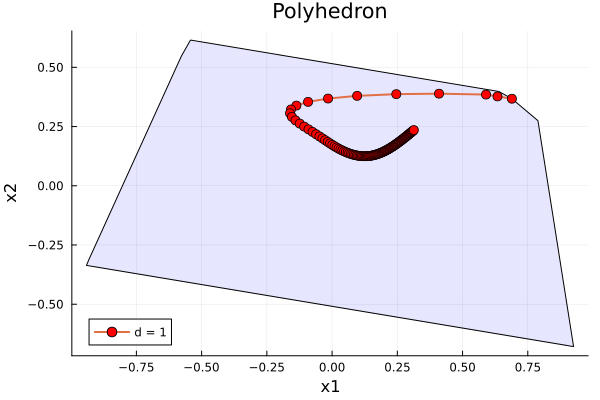

In [32]:
using Plots

F1 = F[:, 1:2]
F2 = F[:, 3:4]

T = Poly.poly_projection(F2)

Poly.plot_poly(T*F1, T*ones(size(F1, 1)))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

Plotando os estados em função de k.

In [ ]:
# Plot x1 and x2 vs time step k
plot(k, x1_traj, label="x1", xlabel="k", ylabel="State value", legend=:best, linewidth=2, marker=:circle, markersize=3)
plot!(k, x2_traj, label="x2", linewidth=2, marker=:square, markersize=3)

In [ ]:
# Plot all states (x1, x2, v, w) vs time step k

# Extract all state components
x1_traj = [p[1] for p in traj1]
x2_traj = [p[2] for p in traj1]
v_traj = [p[3] for p in traj1]
w_traj = [p[4] for p in traj1]

# Time steps
k = 1:length(traj1)

# Create subplots for each state
p1 = plot(k, x1_traj, label="x1", xlabel="k", ylabel="x1", legend=:best, linewidth=2)
p2 = plot(k, x2_traj, label="x2", xlabel="k", ylabel="x2", legend=:best, linewidth=2)
p3 = plot(k, v_traj, label="v (integrated error)", xlabel="k", ylabel="v", legend=:best, linewidth=2)
p4 = plot(k, w_traj, label="w (filtered reference)", xlabel="k", ylabel="w", legend=:best, linewidth=2)

# Combine plots
plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 800))